In [7]:
#!pip install noisereduce

In [8]:
# CELL 1 · IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import librosa
import librosa.display
import noisereduce as nr
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display, Audio, HTML
from ipywidgets import interact, widgets
from tqdm.auto import tqdm

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_PATH = "/kaggle/input/datasets/alieldinalaa/nn-cmp27-dataset"
MACHINES  = ["Machine 1", "Machine 2", "Machine 3"]
STATES    = ["Normal", "Abnormal"]

# ── AUDIO ─────────────────────────────────────────────────────────────────────
TARGET_SR  = 48000

# ── CLEANING PARAMS  (tweak these and rerun cells to trial/error) ─────────────
TRIM_TOP_DB   = 40     # silence threshold dB  — raised from 25 to stop M2 over-trimming
HP_CUTOFF     = 50     # high-pass cutoff Hz   — raise to kill more rumble
HP_ORDER      = 4      # Butterworth order
NOISE_PROP    = 0.75   # spectral subtraction strength  [0.0 – 1.0]
TARGET_RMS    = 0.05   # RMS normalisation target level

# ── PLOT STYLE ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#8a8d9d",
    "ytick.color":      "#8a8d9d",
    "text.color":       "#e0e2ed",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "lines.linewidth":  1.2,
    "font.size":        10,
})
CMAP_MEL   = "magma"
COL_RAW    = "#4e9af1"
COL_CLEAN  = "#43d18a"
COL_NOISE  = "#f16b4e"
COL_RMS    = "#f1c44e"
COL_TRIM   = "#a259f7"

print("✅ Config ready")
print(f"   TRIM_TOP_DB={TRIM_TOP_DB}  HP_CUTOFF={HP_CUTOFF}Hz  "
      f"NOISE_PROP={NOISE_PROP}  TARGET_RMS={TARGET_RMS}")

✅ Config ready
   TRIM_TOP_DB=40  HP_CUTOFF=50Hz  NOISE_PROP=0.75  TARGET_RMS=0.05


In [9]:
# CELL 2 · SCAN FILES & FILE PICKER
# ─────────────────────────────────────────────────────────────────────────────

print("🔍 Scanning files...")
file_registry = []
for machine in MACHINES:
    for state in STATES:
        folder = os.path.join(BASE_PATH, machine, "machine_data", state)
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(".wav"):
                    file_registry.append({
                        "machine": machine, "state": state,
                        "label":   f"{machine}_{state}",
                        "path":    os.path.join(folder, f),
                        "filename": f,
                    })

df_reg = pd.DataFrame(file_registry)
print(f"✅ {len(df_reg)} files found across {df_reg['label'].nunique()} classes")
print(df_reg.groupby(["machine", "state"]).size().to_string())

# ─────────────────────────────────────────────────────────────────────────────
# PICKER FUNCTIONS  — use these throughout the notebook
# ─────────────────────────────────────────────────────────────────────────────

def pick_files(
    n=4,
    mode="random",          # "random" | "ordered"
    same_class=None,        # e.g. "Machine 1_Normal"  or None for mixed
    seed=42,
):
    """
    Return a list of n file-info dicts.

    mode="random"  → random shuffle then take first n
    mode="ordered" → sorted by filename then take first n
    same_class     → restrict to one label; None = sample across all classes
    """
    pool = df_reg.copy()
    if same_class is not None:
        pool = pool[pool["label"] == same_class]
    if pool.empty:
        raise ValueError(f"No files for class '{same_class}'")

    if mode == "random":
        pool = pool.sample(frac=1, random_state=seed).reset_index(drop=True)
    else:
        pool = pool.sort_values("filename").reset_index(drop=True)

    chosen = pool.head(n).to_dict("records")
    print(f"📂 Picked {len(chosen)} files  [{mode}]")
    for r in chosen:
        print(f"   {r['label']:30s}  {r['filename']}")
    return chosen


def pick_one_per_class(seed=42):
    """Pick one file from every class — good for microphone comparison."""
    chosen = []
    for label in sorted(df_reg["label"].unique()):
        row = df_reg[df_reg["label"] == label].sample(1, random_state=seed)
        chosen.append(row.to_dict("records")[0])
    print(f"📂 Picked 1 file per class  ({len(chosen)} files)")
    for r in chosen:
        print(f"   {r['label']:30s}  {r['filename']}")
    return chosen


# Quick-pick helpers
def pick_same(label="Machine 1_Normal", n=3, **kw):
    return pick_files(n=n, same_class=label, **kw)

def pick_mixed(n=6, **kw):
    return pick_files(n=n, same_class=None, **kw)

🔍 Scanning files...
✅ 56236 files found across 6 classes
machine    state   
Machine 1  Abnormal     3176
           Normal      16200
Machine 2  Abnormal     3240
           Normal      16200
Machine 3  Abnormal     3020
           Normal      14400


In [10]:
# CELL 3 · CLEANING PIPELINE  (mirrors training notebook)
# ─────────────────────────────────────────────────────────────────────────────

def _find_quietest_clip(y, sr, clip_dur=0.3):
    frame_len = int(sr * clip_dur)
    hop       = frame_len // 2
    if len(y) <= frame_len:
        return y
    rms_vals   = [np.sqrt(np.mean(y[i:i+frame_len]**2))
                  for i in range(0, len(y)-frame_len, hop)]
    best_start = int(np.argmin(rms_vals)) * hop
    return y[best_start : best_start + frame_len]


def clean_audio(y, sr,
                trim_top_db=TRIM_TOP_DB,
                hp_cutoff=HP_CUTOFF,
                hp_order=HP_ORDER,
                noise_prop=NOISE_PROP,
                target_rms=TARGET_RMS):
    y_trim, _ = librosa.effects.trim(y, top_db=trim_top_db,
                                     frame_length=2048, hop_length=512)
    noise_clip = _find_quietest_clip(y_trim, sr)
    y_nr = nr.reduce_noise(y=y_trim, sr=sr, y_noise=noise_clip,
                           stationary=True, prop_decrease=noise_prop)
    rms = np.sqrt(np.mean(y_nr**2))
    if rms > 1e-9:
        y_nr = y_nr * (target_rms / rms)
    sos  = signal.butter(hp_order, hp_cutoff, btype="hp", fs=sr, output="sos")
    y_hp = signal.sosfilt(sos, y_nr)
    y_hp = np.clip(y_hp, -1.0, 1.0)      # clip AFTER HP filter (filter overshoot was pushing M2 to 1.5)
    return y_hp


def load_pair(file_info, sr=TARGET_SR):
    """Load one file, return (raw, cleaned, sr)."""
    y_raw, sr = librosa.load(file_info["path"], sr=sr)
    y_clean   = clean_audio(y_raw, sr)
    return y_raw, y_clean, sr


print("✅ Cleaning pipeline ready")


✅ Cleaning pipeline ready


✂️ Sampling 10% of the dataset to speed up feature extraction...
⏳ Computing features for 5624 files (raw + cleaned)…


Processing:   0%|          | 0/5624 [00:00<?, ?it/s]

✅ Computed features for 5624 files (6 classes)


,Feature,Raw mean,Raw std,Raw min,Raw max,Clean mean,Clean std,Clean min,Clean max,Δ mean,Δ mean%
0,duration_s,10.6903,0.4624,10.0000,11.0000,9.3759,0.7733,8.0000,11.0000,-1.3144,-12.3%
1,rms,0.0109,0.0200,0.0000,0.1525,0.0496,0.0010,0.0383,0.0500,+0.0387,+355.1%
2,peak_amplitude,0.0952,0.1240,0.0002,0.9999,0.5567,0.3095,0.1727,1.0000,+0.4616,+485.0%
3,dynamic_range_dB,21.1128,6.7368,11.4100,43.5200,19.6700,4.8829,10.7700,28.3300,-1.4428,-6.8%
4,zero_crossing_rate,0.1678,0.0507,0.0643,0.3661,0.1441,0.0526,0.0164,0.5036,-0.0237,-14.1%
5,spectral_centroid_Hz,5878.3303,1337.1895,2732.7400,12960.5300,4765.5342,1253.4776,1036.0000,13096.3500,-1112.7961,-18.9%
6,spectral_bandwidth_Hz,4906.9887,885.0736,2680.0100,8209.6000,4108.3233,699.0706,1847.6400,8010.6700,-798.6654,-16.3%
7,spectral_rolloff_Hz,11236.4527,2551.7066,4664.2600,21737.7100,8797.2979,2061.8506,1426.0300,21730.1700,-2439.1548,-21.7%
8,energy,252.4218,841.0054,0.0003,11168.8906,1108.6715,109.9101,717.6570,1319.9264,+856.2496,+339.2%


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,11.0000,0.0000,9.0843,0.5660,-1.9157
1,rms,0.0132,0.0156,0.0499,0.0010,+0.0367
2,peak_amplitude,0.1359,0.1832,0.4469,0.1258,+0.3110
3,dynamic_range_dB,19.4511,2.7988,18.7785,2.1750,-0.6726
4,zero_crossing_rate,0.1700,0.0631,0.1630,0.0680,-0.0070
5,spectral_centroid_Hz,6179.8519,1495.2121,5166.3964,1621.8857,-1013.4556
6,spectral_bandwidth_Hz,4823.1715,597.6981,4127.0096,684.1805,-696.1619
7,spectral_rolloff_Hz,11635.3771,2103.2970,9726.2041,2369.6934,-1909.1731
8,energy,220.2358,487.9801,1083.6380,66.9036,+863.4021


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,11.0000,0.0000,9.3198,0.6326,-1.6802
1,rms,0.0099,0.0108,0.0500,0.0003,+0.0401
2,peak_amplitude,0.0912,0.1127,0.3993,0.0899,+0.3080
3,dynamic_range_dB,18.3118,1.7815,17.8587,1.7901,-0.4530
4,zero_crossing_rate,0.1696,0.0609,0.1588,0.0612,-0.0108
5,spectral_centroid_Hz,6007.3837,1181.7695,5032.2712,1280.3101,-975.1124
6,spectral_bandwidth_Hz,4697.5884,384.4117,4031.8473,462.0490,-665.7411
7,spectral_rolloff_Hz,11240.0146,1404.2919,9471.8525,1657.4209,-1768.1621
8,energy,112.9691,208.0434,1116.9838,74.6679,+1004.0147


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,11.0000,0.0000,9.3025,0.9067,-1.6975
1,rms,0.0025,0.0012,0.0489,0.0013,+0.0464
2,peak_amplitude,0.0956,0.0571,0.9633,0.1094,+0.8677
3,dynamic_range_dB,30.3919,3.9328,25.8137,1.3161,-4.5782
4,zero_crossing_rate,0.1984,0.0261,0.1516,0.0319,-0.0468
5,spectral_centroid_Hz,6817.2392,526.4189,5153.1170,671.2429,-1664.1222
6,spectral_bandwidth_Hz,5766.0837,369.0796,4615.2413,322.0680,-1150.8424
7,spectral_rolloff_Hz,13176.4897,1250.9404,9111.0089,1136.5225,-4065.4808
8,energy,4.1390,3.4946,1071.2941,136.9803,+1067.1551


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,11.0000,0.0000,9.4770,0.9515,-1.5230
1,rms,0.0021,0.0007,0.0489,0.0014,+0.0468
2,peak_amplitude,0.0698,0.0438,0.9492,0.1219,+0.8793
3,dynamic_range_dB,29.0960,3.9274,25.6673,1.4978,-3.4287
4,zero_crossing_rate,0.2034,0.0198,0.1604,0.0246,-0.0430
5,spectral_centroid_Hz,7005.2224,309.9176,5351.0247,479.7814,-1654.1976
6,spectral_bandwidth_Hz,5896.0535,366.5420,4736.3214,292.3800,-1159.7321
7,spectral_rolloff_Hz,13709.5060,1057.5479,9394.5830,915.0811,-4314.9230
8,energy,2.5787,1.4818,1091.9012,152.3656,+1089.3225


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,10.0000,0.0000,9.2249,0.7677,-0.7751
1,rms,0.0239,0.0372,0.0500,0.0000,+0.0260
2,peak_amplitude,0.1504,0.2310,0.3730,0.1862,+0.2227
3,dynamic_range_dB,16.6722,3.1557,16.7038,3.3394,+0.0316
4,zero_crossing_rate,0.1365,0.0279,0.1143,0.0509,-0.0222
5,spectral_centroid_Hz,4644.0282,781.4040,3872.4060,1229.3109,-771.6222
6,spectral_bandwidth_Hz,4057.0279,557.5808,3498.9668,611.3803,-558.0612
7,spectral_rolloff_Hz,8611.6055,1743.7105,7335.6690,2491.6954,-1275.9365
8,energy,938.3188,2037.2887,1106.8631,92.2265,+168.5444


,Feature,Raw μ,Raw σ,Clean μ,Clean σ,Δ μ
0,duration_s,10.0000,0.0000,9.4378,0.6677,-0.5622
1,rms,0.0206,0.0291,0.0500,0.0000,+0.0294
2,peak_amplitude,0.1074,0.1498,0.2636,0.0267,+0.1562
3,dynamic_range_dB,14.4931,0.7563,14.3973,0.8647,-0.0958
4,zero_crossing_rate,0.1248,0.0232,0.1096,0.0461,-0.0152
5,spectral_centroid_Hz,4446.4116,766.0236,3818.3570,1199.6430,-628.0545
6,spectral_bandwidth_Hz,4033.3349,579.2192,3497.4735,639.4050,-535.8615
7,spectral_rolloff_Hz,8476.1454,1779.2678,7397.2960,2493.4189,-1078.8494
8,energy,609.5033,1209.0677,1132.5039,80.1192,+523.0006


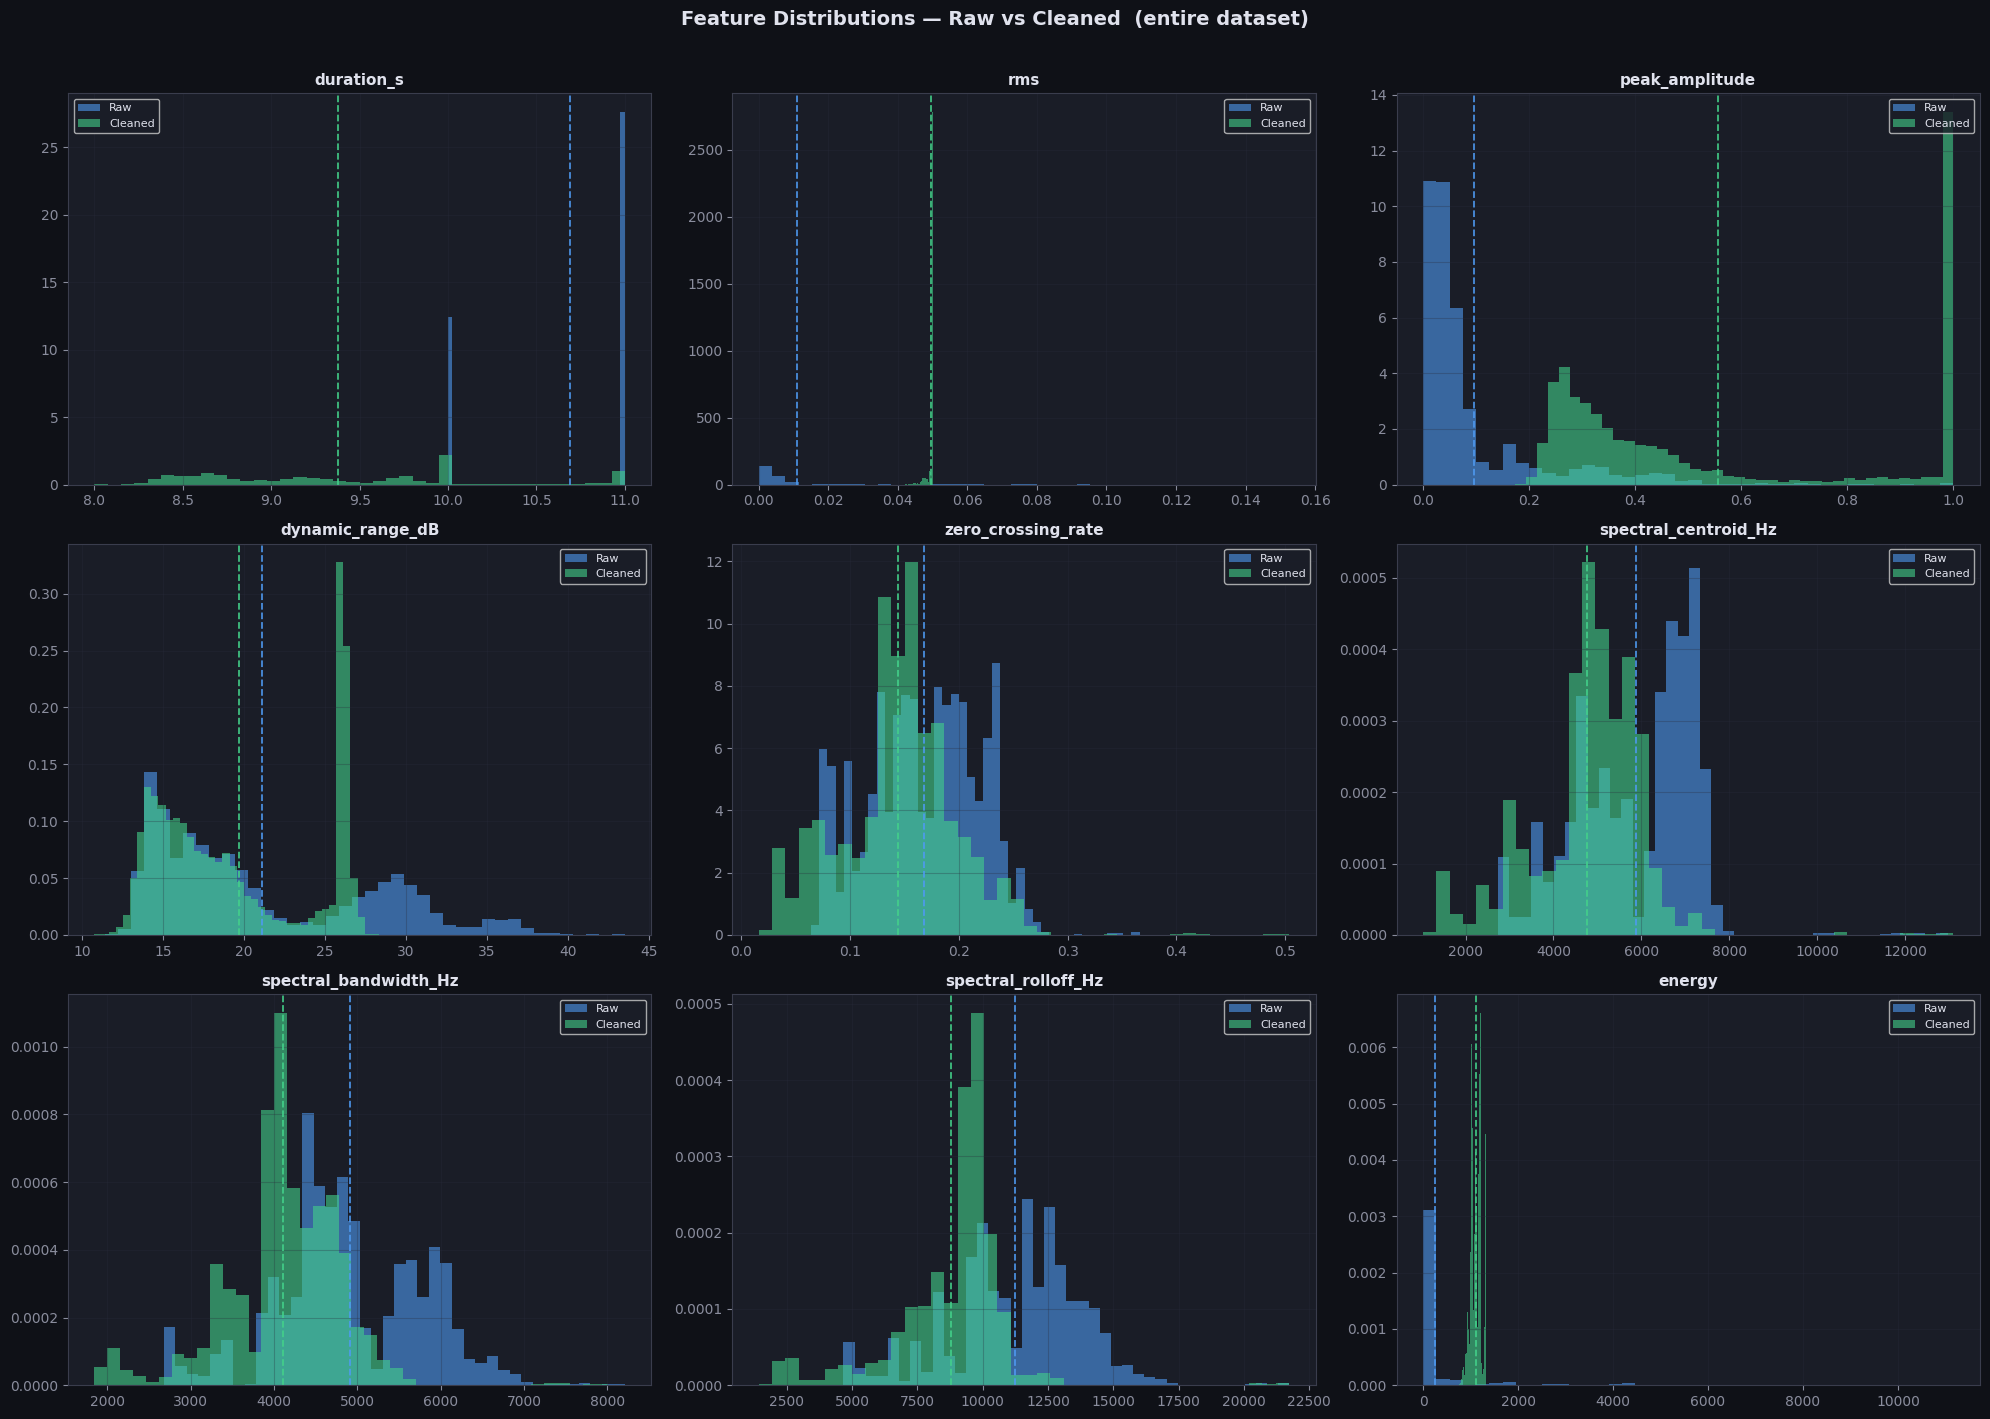

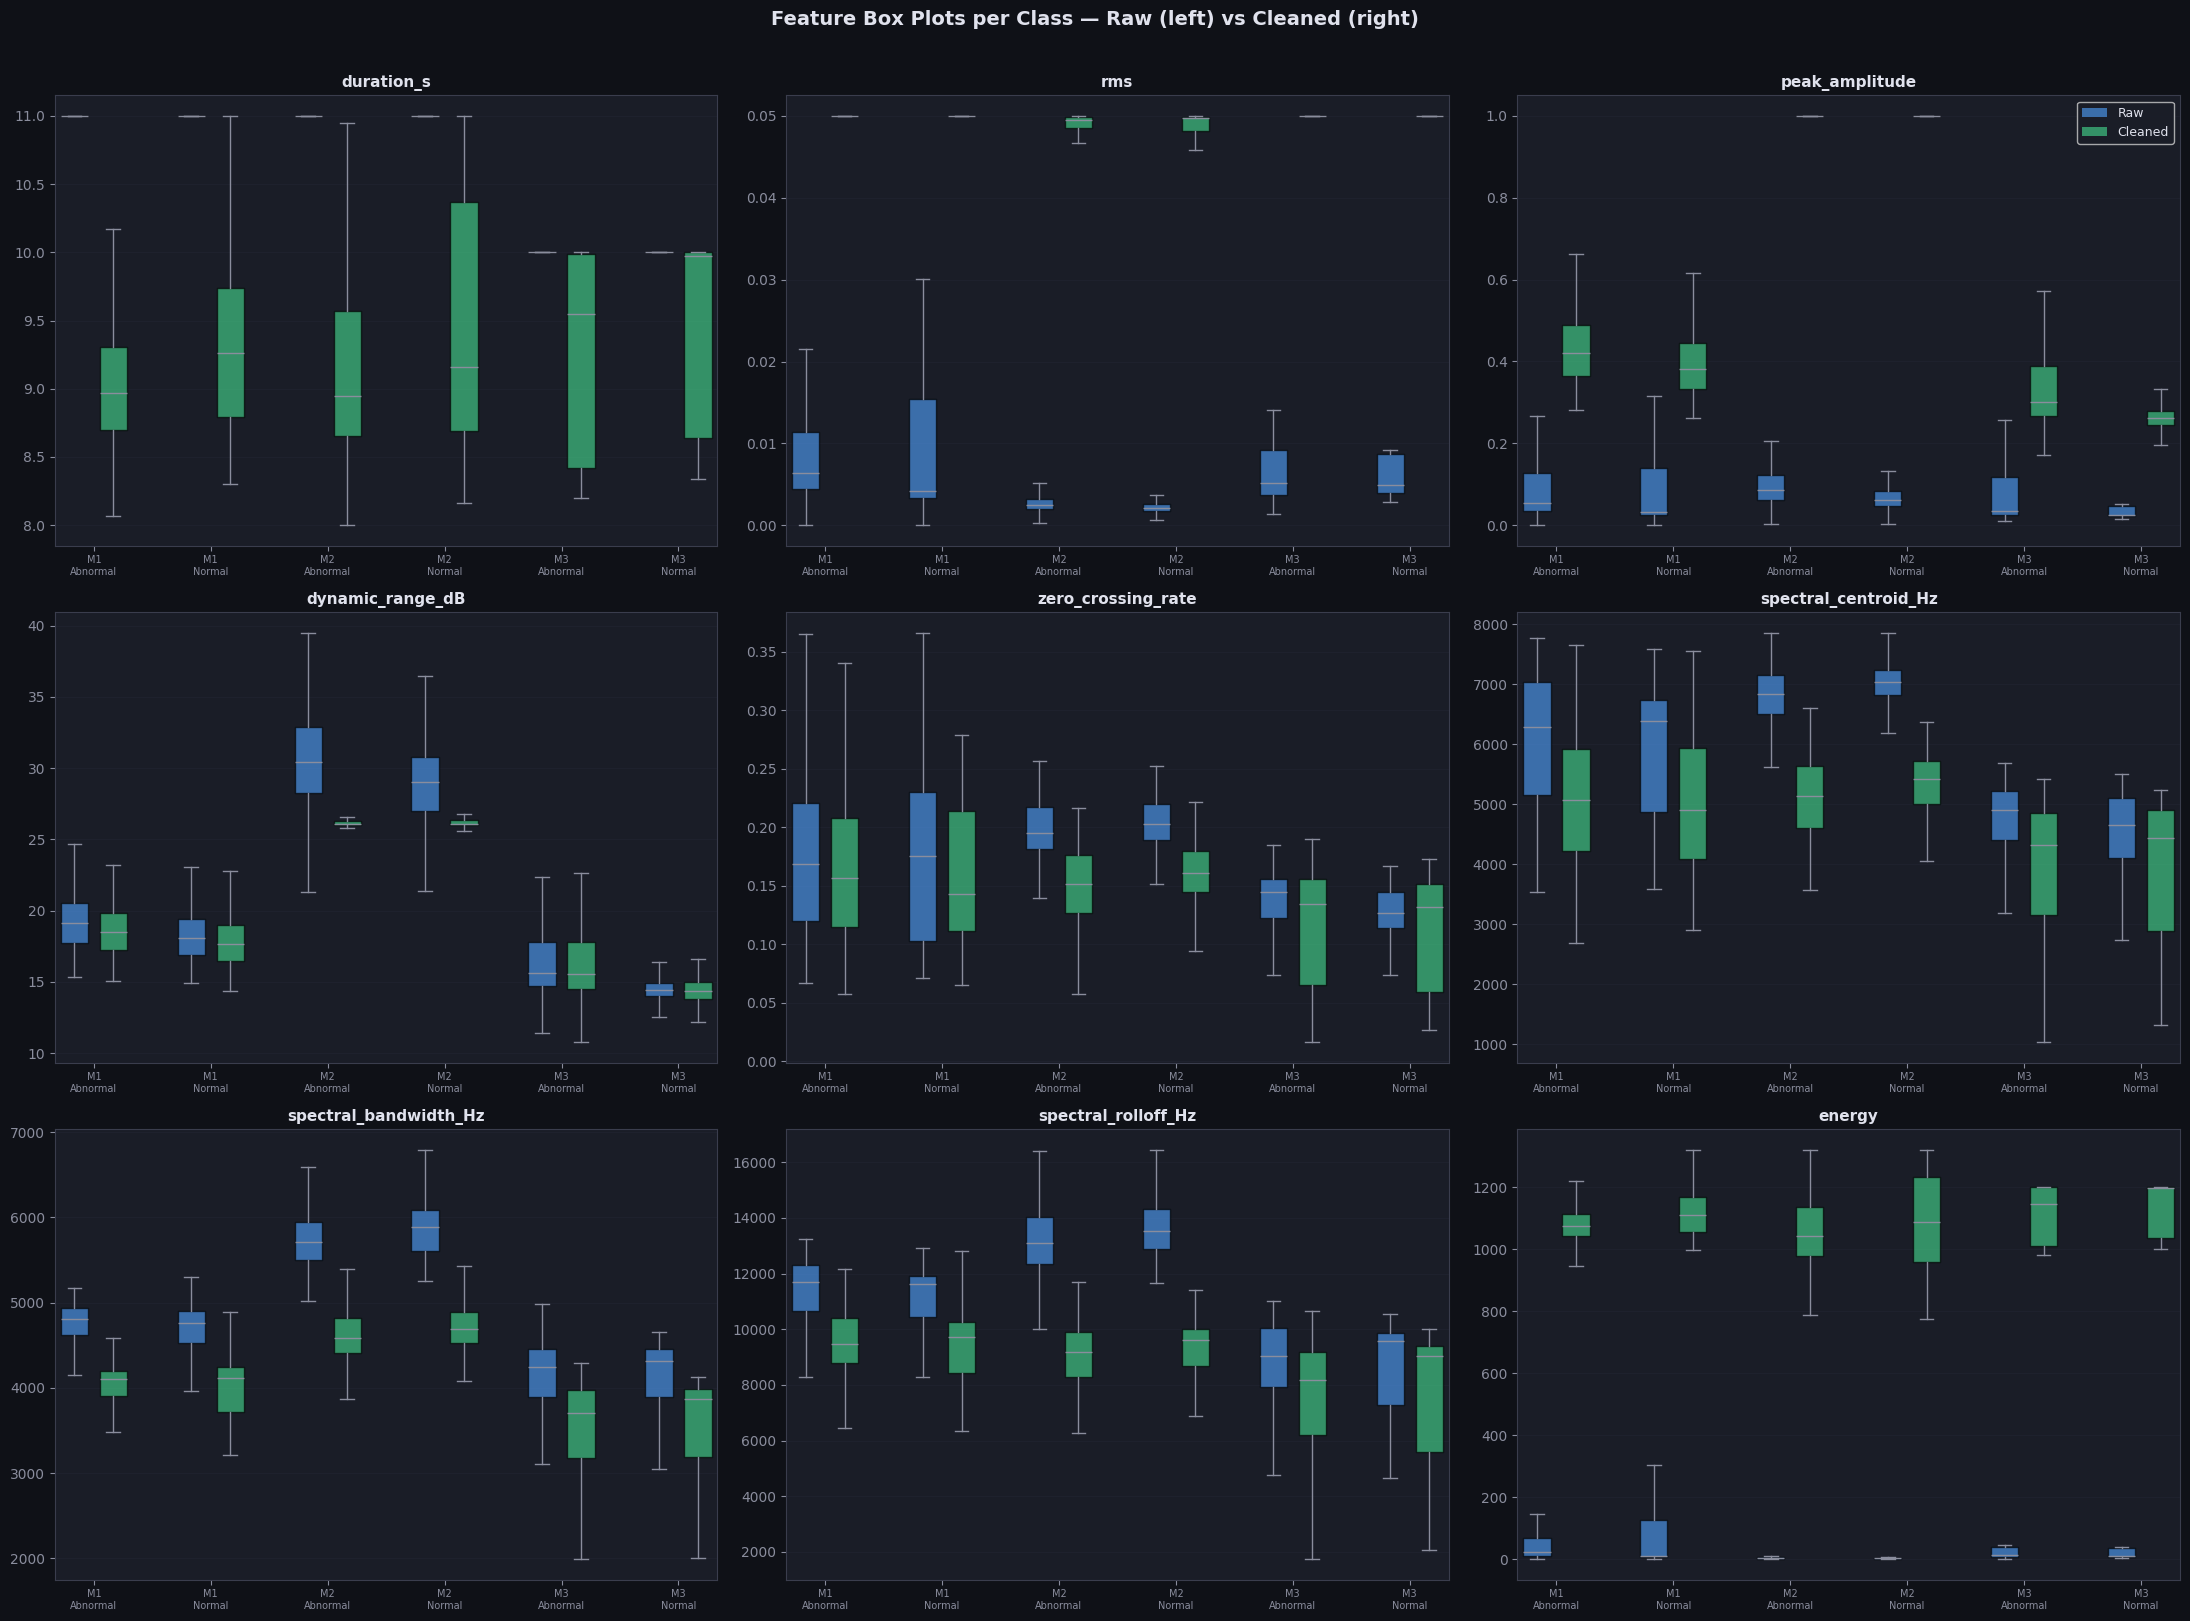

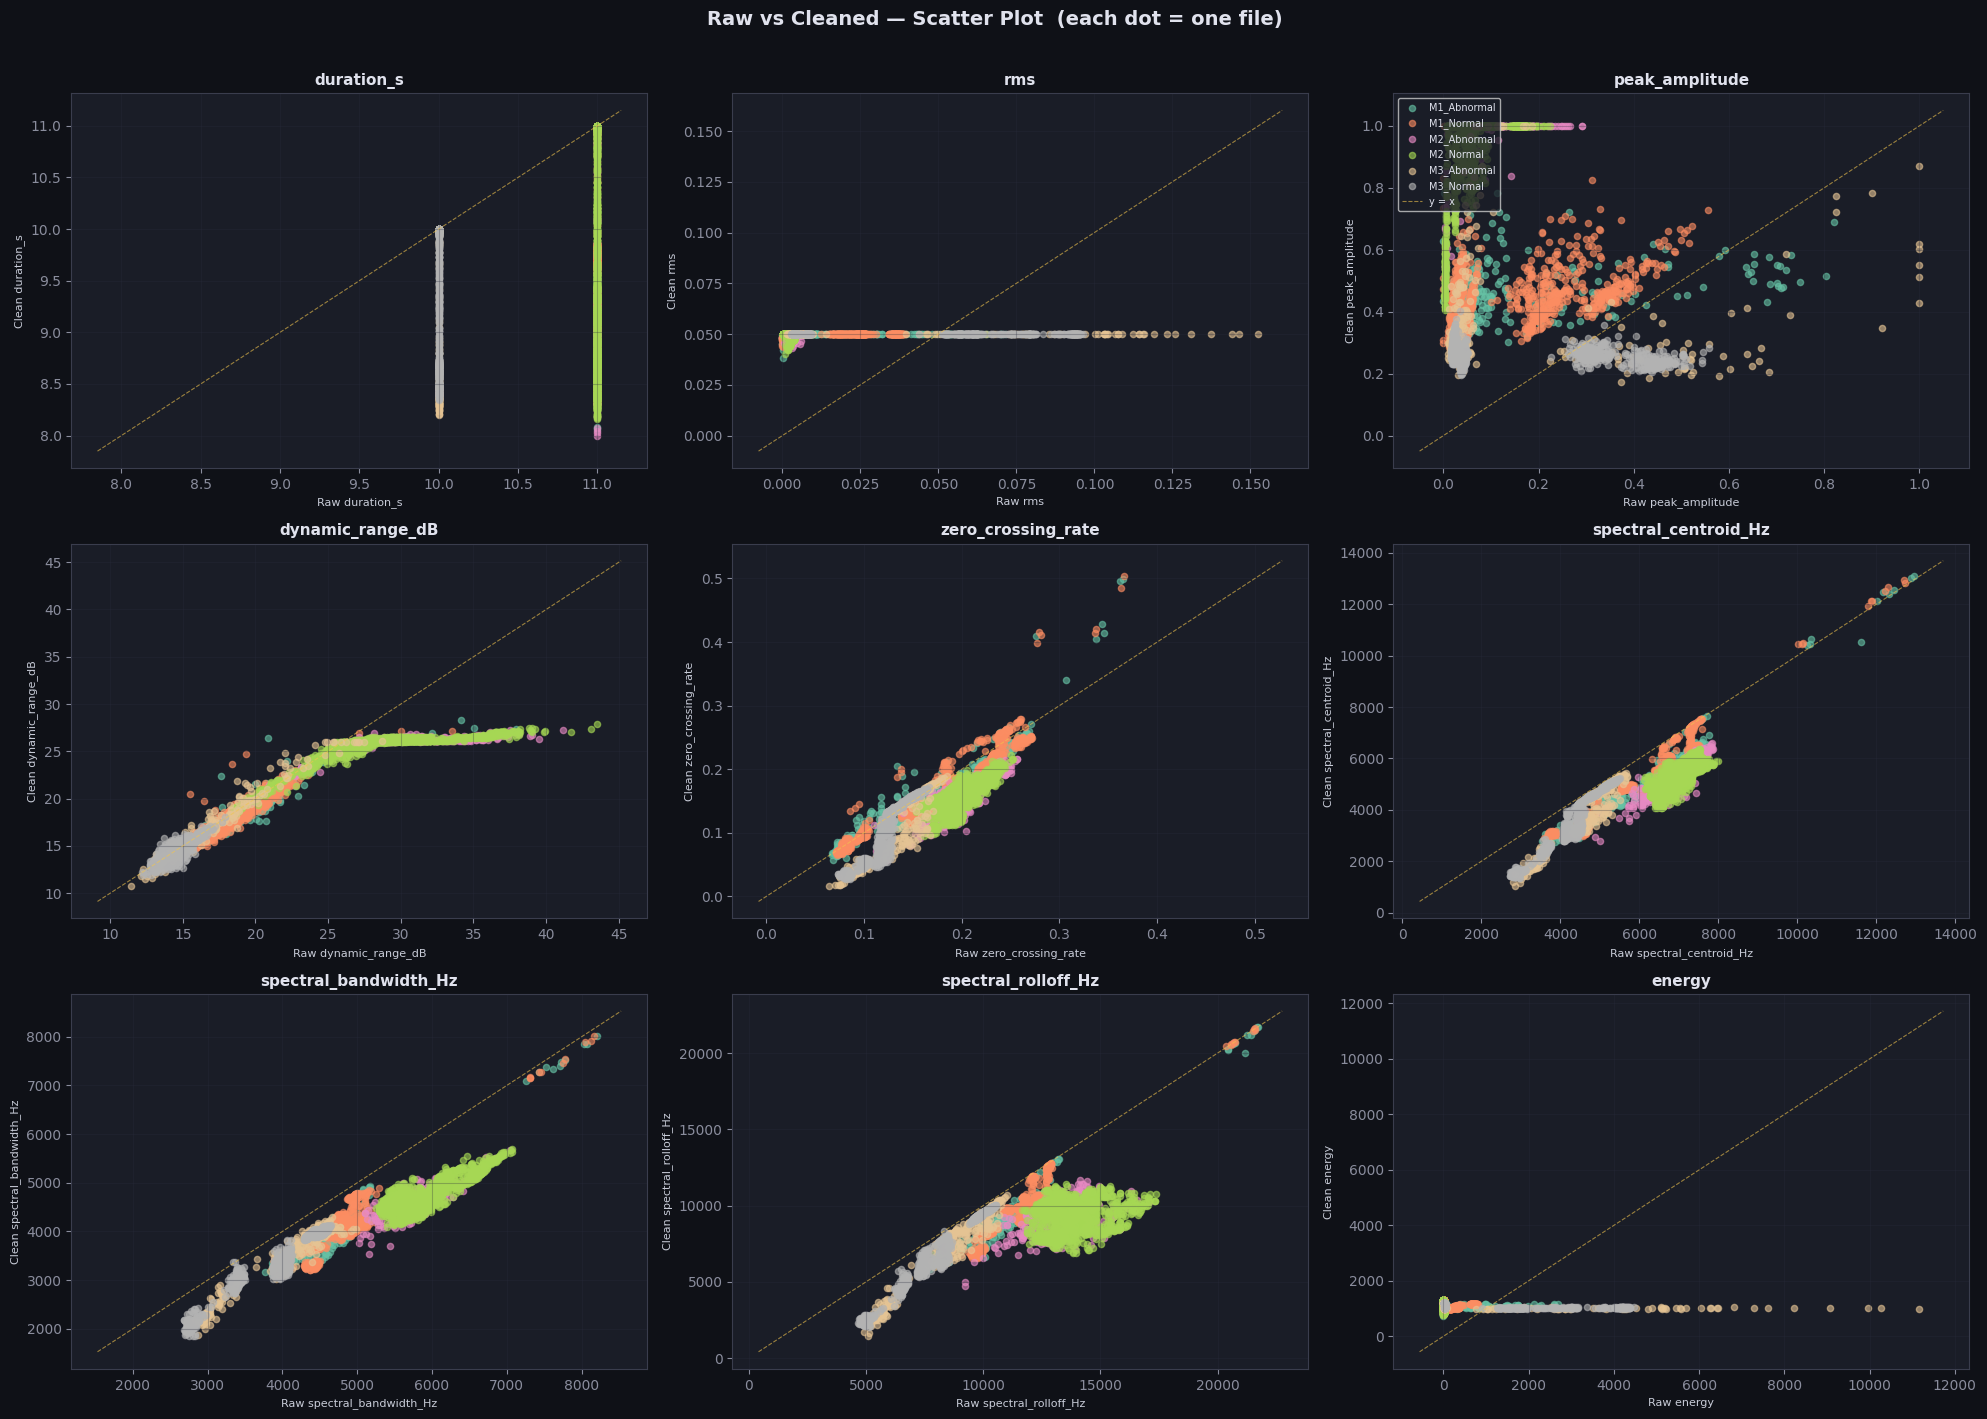

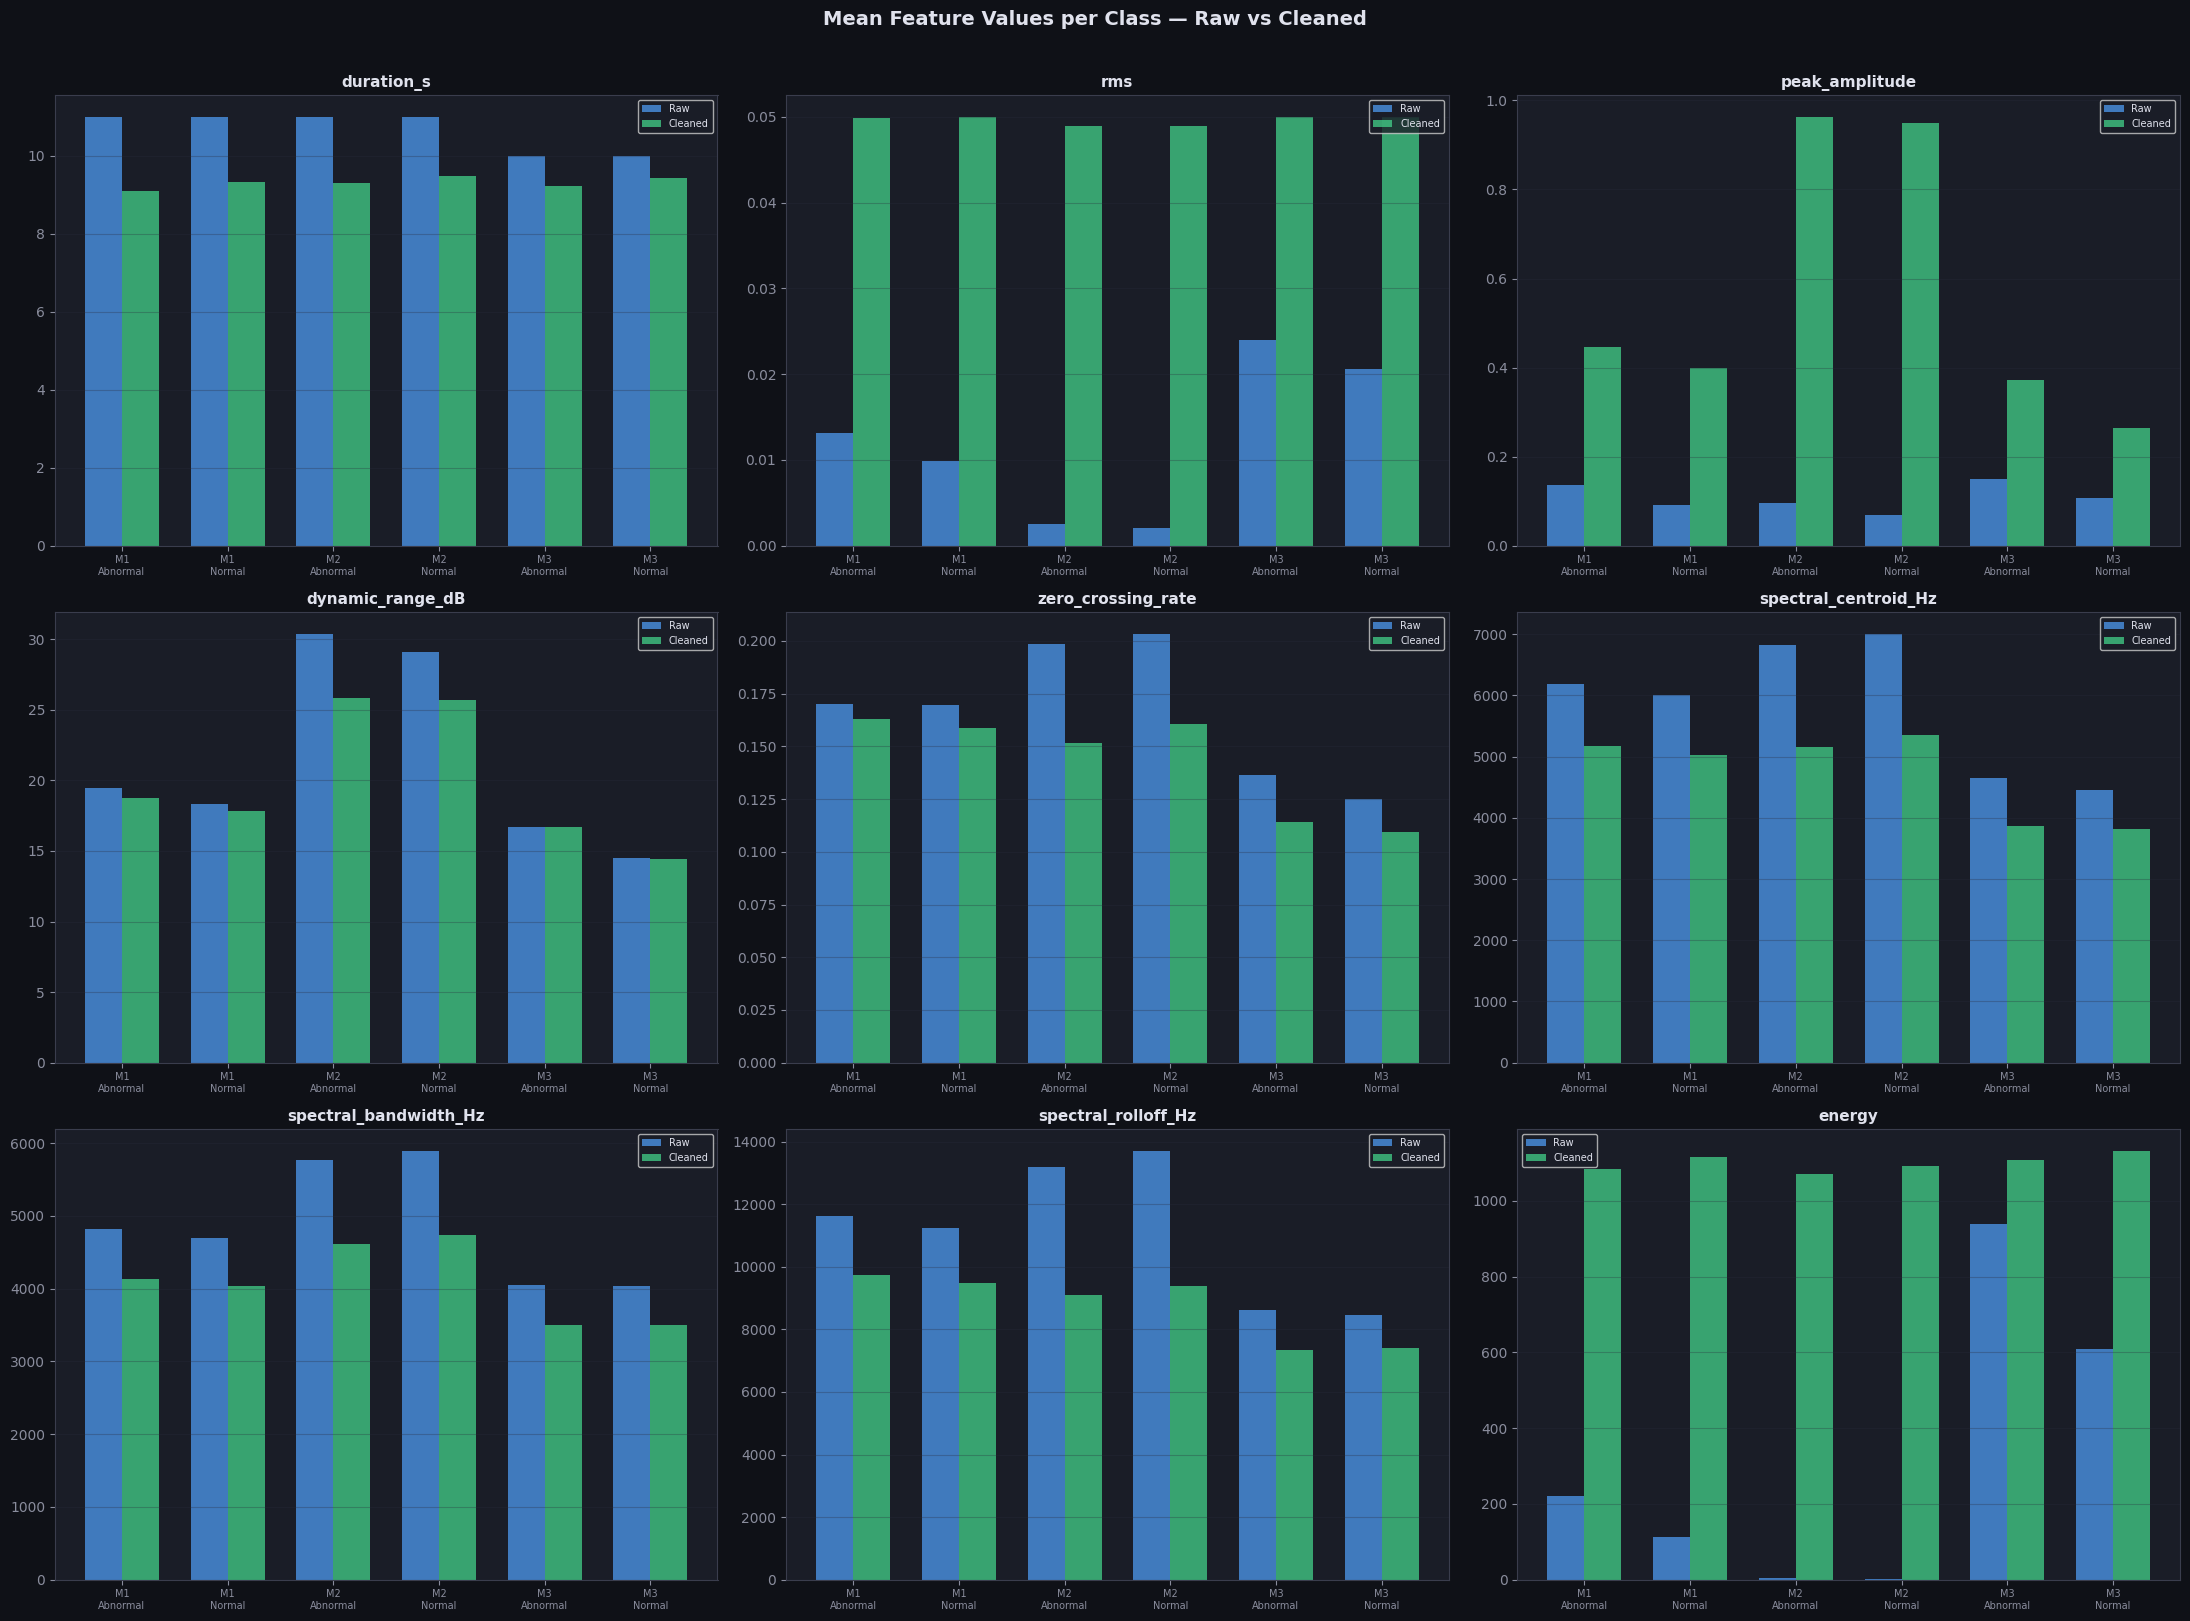

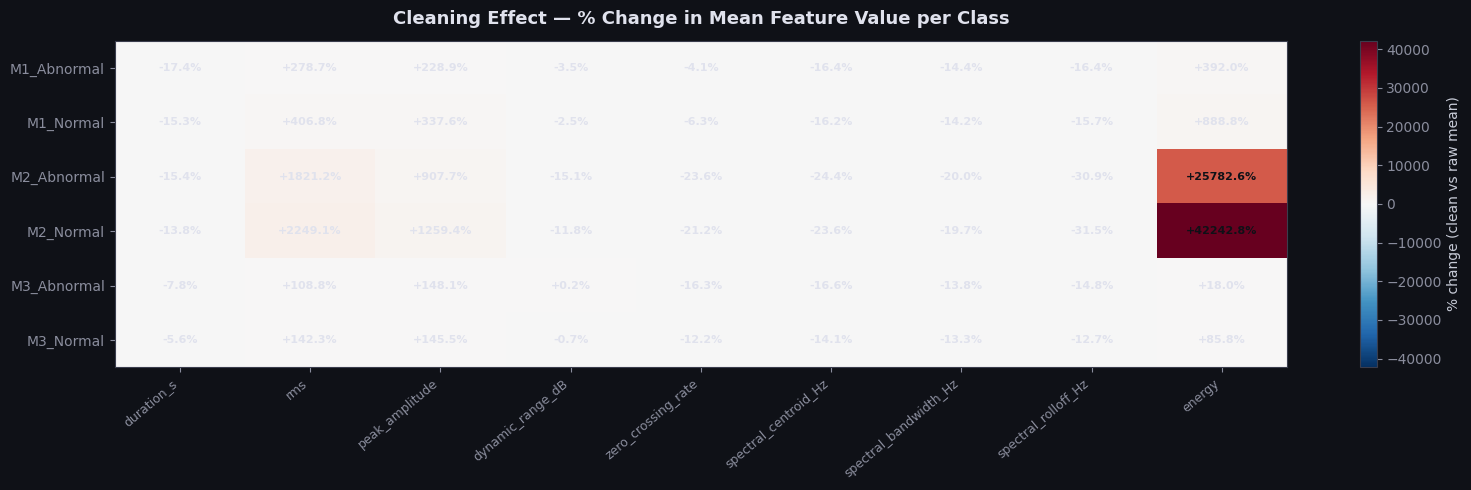

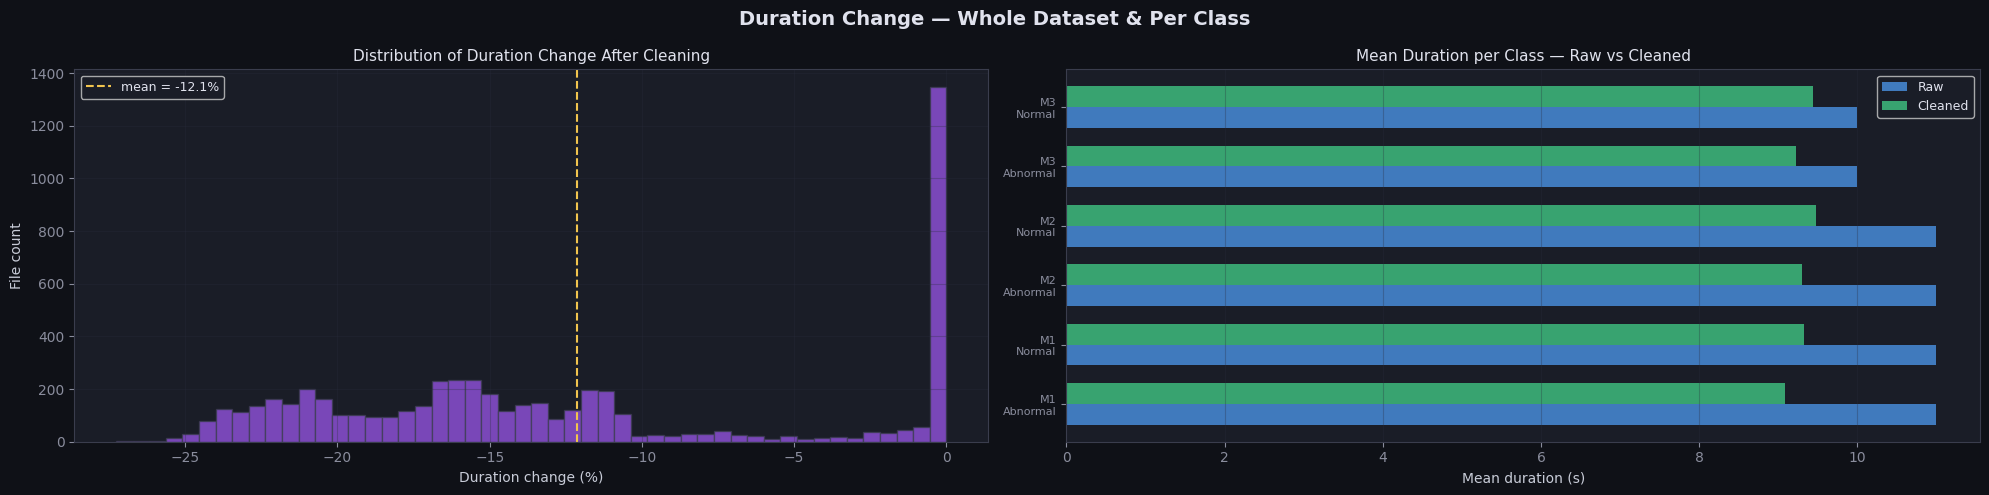

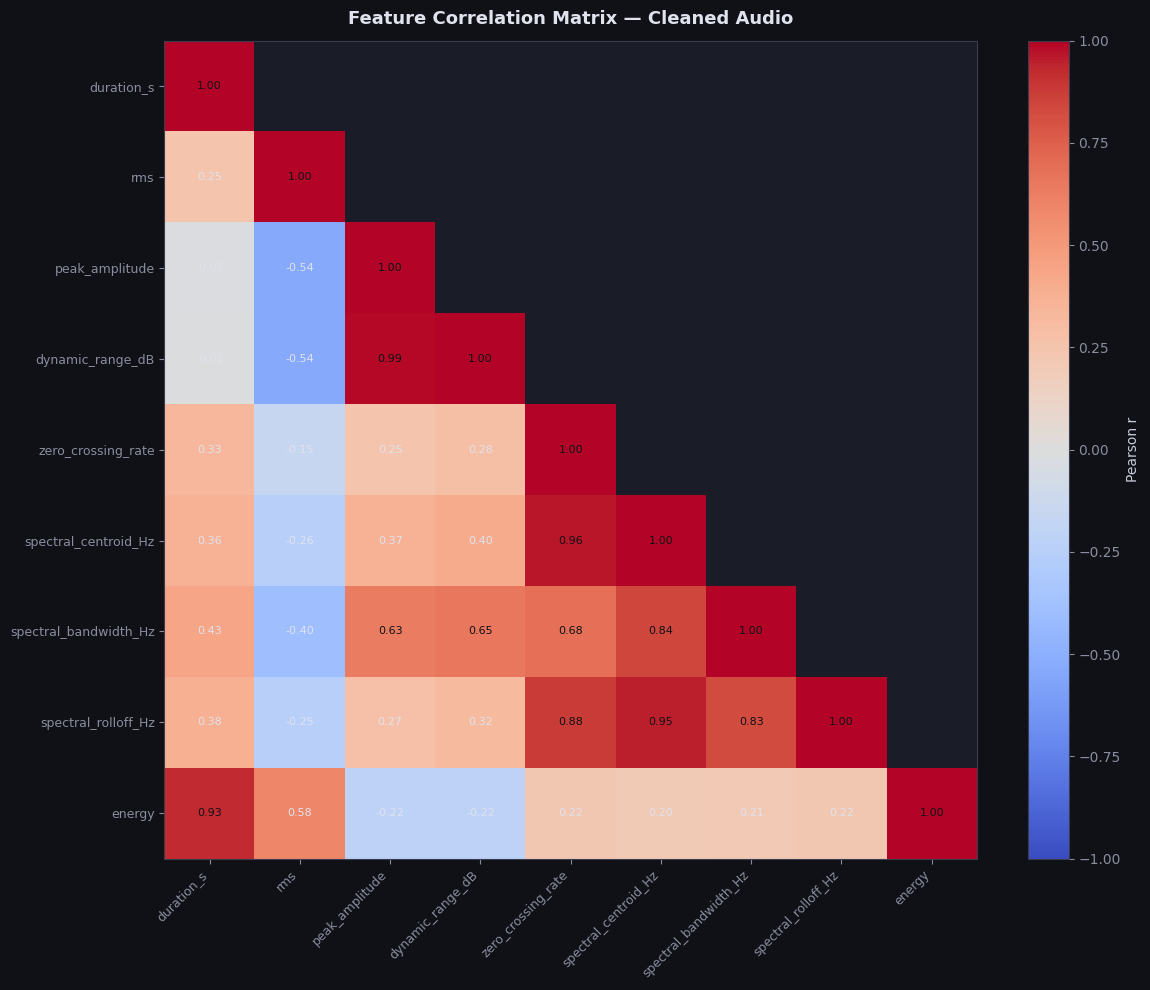

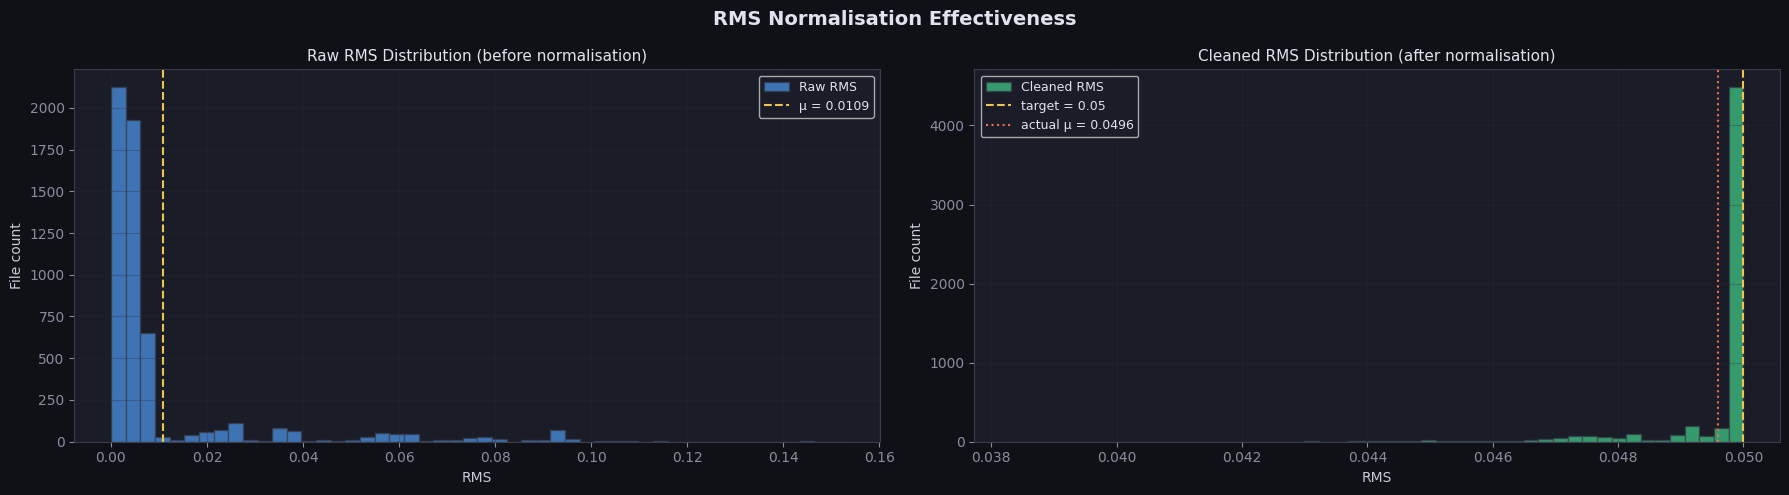


════════════════════════════════════════════════════════════════════════════════
📊  DATASET CLEANING SUMMARY
════════════════════════════════════════════════════════════════════════════════
   Total files processed       : 5624
   Classes                     : 6
   Mean raw duration           : 10.69s
   Mean cleaned duration       : 9.38s
   Mean duration reduction     : -12.1%
   Raw RMS  (μ ± σ)           : 0.01090 ± 0.01996
   Clean RMS (μ ± σ)          : 0.04960 ± 0.00101
   RMS spread reduction        : 94.9%
   Mean spectral centroid shift: -1112.8 Hz
════════════════════════════════════════════════════════════════════════════════
   ✅ df_stats DataFrame is available for further analysis
════════════════════════════════════════════════════════════════════════════════


In [11]:
# CELL 5 · FULL-DATASET STATISTICAL COMPARISON — BEFORE vs AFTER CLEANING
#
# Loads EVERY file, computes per-file audio features (raw & cleaned),
# then produces:
#   • A summary statistics table   (whole dataset + per class)
#   • 8 publication-quality plots   comparing distributions
#
# Features computed per file:
#   duration_s, rms, peak_amplitude, dynamic_range_dB,
#   zero_crossing_rate, spectral_centroid_Hz, spectral_bandwidth_Hz,
#   spectral_rolloff_Hz, energy
# ─────────────────────────────────────────────────────────────────────────────

# ── 5a · COMPUTE STATS FOR EVERY FILE (20% SAMPLED) ──────────────────────────

def compute_features(y, sr):
    """Return a dict of scalar audio features for a signal y."""
    duration   = len(y) / sr
    rms        = float(np.sqrt(np.mean(y**2)))
    peak       = float(np.max(np.abs(y)))
    dyn_range  = float(20 * np.log10((peak + 1e-12) / (rms + 1e-12)))
    zcr        = float(np.mean(librosa.feature.zero_crossing_rate(y=y)))
    cent       = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    bw         = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
    rolloff    = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))
    energy     = float(np.sum(y**2))
    return dict(
        duration_s          = round(duration, 4),
        rms                 = round(rms, 6),
        peak_amplitude      = round(peak, 6),
        dynamic_range_dB    = round(dyn_range, 2),
        zero_crossing_rate  = round(zcr, 6),
        spectral_centroid_Hz= round(cent, 2),
        spectral_bandwidth_Hz= round(bw, 2),
        spectral_rolloff_Hz = round(rolloff, 2),
        energy              = round(energy, 6),
    )

# We use groupby to ensure we grab exactly x% from EVERY class (stratified)
print("✂️ Sampling 10% of the dataset to speed up feature extraction...")
df_sampled_stats = df_reg.groupby('label', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

rows = []
print(f"⏳ Computing features for {len(df_sampled_stats)} files (raw + cleaned)…")
for idx, finfo in tqdm(df_sampled_stats.iterrows(), total=len(df_sampled_stats), desc="Processing"):
    y_raw, y_clean, sr_ = load_pair(finfo.to_dict(), TARGET_SR)

    feat_raw   = compute_features(y_raw,   sr_)
    feat_clean = compute_features(y_clean, sr_)

    row = {
        "machine":  finfo["machine"],
        "state":    finfo["state"],
        "label":    finfo["label"],
        "filename": finfo["filename"],
    }
    for k, v in feat_raw.items():
        row[f"raw_{k}"] = v
    for k, v in feat_clean.items():
        row[f"clean_{k}"] = v
    rows.append(row)

df_stats = pd.DataFrame(rows)
print(f"✅ Computed features for {len(df_stats)} files ({df_stats['label'].nunique()} classes)")

# ── 5b · WHOLE-DATASET SUMMARY TABLE ─────────────────────────────────────────

FEATURES = [
    "duration_s", "rms", "peak_amplitude", "dynamic_range_dB",
    "zero_crossing_rate", "spectral_centroid_Hz",
    "spectral_bandwidth_Hz", "spectral_rolloff_Hz", "energy",
]

summary_rows = []
for feat in FEATURES:
    r = df_stats[f"raw_{feat}"]
    c = df_stats[f"clean_{feat}"]
    summary_rows.append({
        "Feature": feat,
        "Raw mean":   f"{r.mean():.4f}",
        "Raw std":    f"{r.std():.4f}",
        "Raw min":    f"{r.min():.4f}",
        "Raw max":    f"{r.max():.4f}",
        "Clean mean": f"{c.mean():.4f}",
        "Clean std":  f"{c.std():.4f}",
        "Clean min":  f"{c.min():.4f}",
        "Clean max":  f"{c.max():.4f}",
        "Δ mean":     f"{c.mean() - r.mean():+.4f}",
        "Δ mean%":    f"{((c.mean() - r.mean()) / (r.mean() + 1e-12)) * 100:+.1f}%",
    })

df_summary = pd.DataFrame(summary_rows)
display(HTML(
    "<h3 style='color:#e0e2ed;font-family:monospace'>📊 Whole-Dataset Summary — Raw vs Cleaned</h3>"
))
display(df_summary.style.set_properties(**{
    'background-color': '#1a1d27',
    'color': '#c8ccd8',
    'border': '1px solid #3a3d4d',
    'font-family': 'monospace',
    'font-size': '11px',
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#252836'),
        ('color', '#e0e2ed'),
        ('font-size', '11px'),
        ('border', '1px solid #3a3d4d'),
    ]},
]))


# ── 5c · PER-CLASS SUMMARY TABLE ─────────────────────────────────────────────

display(HTML(
    "<h3 style='color:#e0e2ed;font-family:monospace'>📊 Per-Class Summary — Raw vs Cleaned</h3>"
))

for label in sorted(df_stats["label"].unique()):
    sub = df_stats[df_stats["label"] == label]
    class_rows = []
    for feat in FEATURES:
        r = sub[f"raw_{feat}"]
        c = sub[f"clean_{feat}"]
        class_rows.append({
            "Feature": feat,
            "Raw μ":  f"{r.mean():.4f}",
            "Raw σ":  f"{r.std():.4f}",
            "Clean μ":f"{c.mean():.4f}",
            "Clean σ":f"{c.std():.4f}",
            "Δ μ":    f"{c.mean() - r.mean():+.4f}",
        })
    df_class = pd.DataFrame(class_rows)
    display(HTML(
        f"<div style='margin:10px 0 4px;color:#4e9af1;font-family:monospace;"
        f"font-weight:bold;font-size:13px'>{label}  ({len(sub)} files)</div>"
    ))
    display(df_class.style.set_properties(**{
        'background-color': '#1a1d27',
        'color': '#c8ccd8',
        'border': '1px solid #3a3d4d',
        'font-family': 'monospace',
        'font-size': '11px',
    }).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#252836'),
            ('color', '#e0e2ed'),
            ('font-size', '11px'),
            ('border', '1px solid #3a3d4d'),
        ]},
    ]))


# ── 5d · PLOT 1: FEATURE DISTRIBUTIONS (histograms) ──────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Feature Distributions — Raw vs Cleaned  (entire dataset)",
             fontsize=14, color="#e0e2ed", fontweight="bold", y=1.01)

for ax, feat in zip(axes.ravel(), FEATURES):
    r = df_stats[f"raw_{feat}"]
    c = df_stats[f"clean_{feat}"]
    ax.hist(r, bins=40, color=COL_RAW,   alpha=0.6, label="Raw",     density=True)
    ax.hist(c, bins=40, color=COL_CLEAN, alpha=0.6, label="Cleaned", density=True)
    ax.axvline(r.mean(), color=COL_RAW,   linestyle="--", linewidth=1.3, alpha=0.9)
    ax.axvline(c.mean(), color=COL_CLEAN, linestyle="--", linewidth=1.3, alpha=0.9)
    ax.set_title(feat, color="#e0e2ed", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── 5e · PLOT 2: BOX PLOTS PER CLASS ─────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Feature Box Plots per Class — Raw (left) vs Cleaned (right)",
             fontsize=14, color="#e0e2ed", fontweight="bold", y=1.01)

labels_sorted = sorted(df_stats["label"].unique())

for ax, feat in zip(axes.ravel(), FEATURES):
    data_raw, data_clean, positions_raw, positions_clean, tick_labels = [], [], [], [], []
    for i, label in enumerate(labels_sorted):
        sub = df_stats[df_stats["label"] == label]
        data_raw.append(sub[f"raw_{feat}"].values)
        data_clean.append(sub[f"clean_{feat}"].values)
        positions_raw.append(i * 3)
        positions_clean.append(i * 3 + 1)
        tick_labels.append(label.replace("Machine ", "M").replace("_", "\n"))

    bp_raw = ax.boxplot(data_raw, positions=positions_raw, widths=0.7,
                        patch_artist=True, showfliers=False)
    bp_clean = ax.boxplot(data_clean, positions=positions_clean, widths=0.7,
                          patch_artist=True, showfliers=False)

    for patch in bp_raw["boxes"]:
        patch.set_facecolor(COL_RAW)
        patch.set_alpha(0.65)
    for patch in bp_clean["boxes"]:
        patch.set_facecolor(COL_CLEAN)
        patch.set_alpha(0.65)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp_raw[element]:
            line.set_color("#8a8d9d")
        for line in bp_clean[element]:
            line.set_color("#8a8d9d")

    ax.set_xticks([i * 3 + 0.5 for i in range(len(labels_sorted))])
    ax.set_xticklabels(tick_labels, fontsize=7)
    ax.set_title(feat, color="#e0e2ed", fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COL_RAW, alpha=0.65, label="Raw"),
                   Patch(facecolor=COL_CLEAN, alpha=0.65, label="Cleaned")]
axes[0][2].legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


# ── 5f · PLOT 3: RAW vs CLEANED SCATTER (per feature) ────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Raw vs Cleaned — Scatter Plot  (each dot = one file)",
             fontsize=14, color="#e0e2ed", fontweight="bold", y=1.01)

palette_map = {}
label_colors = plt.cm.Set2(np.linspace(0, 1, len(labels_sorted)))
for label, col in zip(labels_sorted, label_colors):
    palette_map[label] = col

for ax, feat in zip(axes.ravel(), FEATURES):
    for label in labels_sorted:
        sub = df_stats[df_stats["label"] == label]
        ax.scatter(sub[f"raw_{feat}"], sub[f"clean_{feat}"],
                   color=palette_map[label], alpha=0.6, s=20,
                   label=label.replace("Machine ", "M"))

    # Identity line
    all_vals = np.concatenate([df_stats[f"raw_{feat}"].values,
                                df_stats[f"clean_{feat}"].values])
    lo, hi = all_vals.min(), all_vals.max()
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            color="#f1c44e", linestyle="--", linewidth=0.8, alpha=0.6,
            label="y = x")

    ax.set_xlabel(f"Raw {feat}", fontsize=8)
    ax.set_ylabel(f"Clean {feat}", fontsize=8)
    ax.set_title(feat, color="#e0e2ed", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[0][2].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()


# ── 5g · PLOT 4: MEAN FEATURE BAR CHART — RAW vs CLEANED PER CLASS ───────────

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Mean Feature Values per Class — Raw vs Cleaned",
             fontsize=14, color="#e0e2ed", fontweight="bold", y=1.01)

x_pos = np.arange(len(labels_sorted))
bar_w = 0.35

for ax, feat in zip(axes.ravel(), FEATURES):
    means_raw   = [df_stats[df_stats["label"] == l][f"raw_{feat}"].mean()
                   for l in labels_sorted]
    means_clean = [df_stats[df_stats["label"] == l][f"clean_{feat}"].mean()
                   for l in labels_sorted]

    ax.bar(x_pos - bar_w/2, means_raw,   bar_w, color=COL_RAW,   alpha=0.75,
           label="Raw")
    ax.bar(x_pos + bar_w/2, means_clean, bar_w, color=COL_CLEAN, alpha=0.75,
           label="Cleaned")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([l.replace("Machine ", "M").replace("_", "\n")
                        for l in labels_sorted], fontsize=7)
    ax.set_title(feat, color="#e0e2ed", fontsize=11, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ── 5h · PLOT 5: PERCENTAGE CHANGE HEATMAP ───────────────────────────────────

pct_change_data = []
for label in labels_sorted:
    sub  = df_stats[df_stats["label"] == label]
    row  = {}
    for feat in FEATURES:
        raw_mean   = sub[f"raw_{feat}"].mean()
        clean_mean = sub[f"clean_{feat}"].mean()
        pct = ((clean_mean - raw_mean) / (abs(raw_mean) + 1e-12)) * 100
        row[feat] = round(pct, 1)
    pct_change_data.append(row)

df_pct = pd.DataFrame(pct_change_data, index=[
    l.replace("Machine ", "M") for l in labels_sorted
])

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

# Diverging colourmap centred at 0
vmax = max(abs(df_pct.values.min()), abs(df_pct.values.max()), 50)
im = ax.imshow(df_pct.values, cmap="RdBu_r", aspect="auto",
               vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=ax, label="% change (clean vs raw mean)")

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(df_pct)))
ax.set_yticklabels(df_pct.index, fontsize=10)

# Annotate cells with values
for i in range(len(df_pct)):
    for j in range(len(FEATURES)):
        val = df_pct.values[i, j]
        color = "#0f1117" if abs(val) > vmax * 0.6 else "#e0e2ed"
        ax.text(j, i, f"{val:+.1f}%", ha="center", va="center",
                fontsize=8, color=color, fontweight="bold")

ax.set_title("Cleaning Effect — % Change in Mean Feature Value per Class",
             color="#e0e2ed", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


# ── 5i · PLOT 6: DURATION CHANGE — WATERFALL ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Duration Change — Whole Dataset & Per Class",
             fontsize=14, color="#e0e2ed", fontweight="bold")

# Left: histogram of duration reduction %
pct_dur = ((df_stats["clean_duration_s"] - df_stats["raw_duration_s"])
           / df_stats["raw_duration_s"] * 100)
axes[0].hist(pct_dur, bins=50, color=COL_TRIM, alpha=0.7, edgecolor="#3a3d4d")
axes[0].axvline(pct_dur.mean(), color=COL_RMS, linestyle="--", linewidth=1.5,
                label=f"mean = {pct_dur.mean():.1f}%")
axes[0].set_xlabel("Duration change (%)")
axes[0].set_ylabel("File count")
axes[0].set_title("Distribution of Duration Change After Cleaning",
                   color="#e0e2ed", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: per-class mean duration raw vs clean
raw_dur_means   = [df_stats[df_stats["label"] == l]["raw_duration_s"].mean()
                   for l in labels_sorted]
clean_dur_means = [df_stats[df_stats["label"] == l]["clean_duration_s"].mean()
                   for l in labels_sorted]

axes[1].barh(x_pos - bar_w/2, raw_dur_means,   bar_w, color=COL_RAW,
             alpha=0.75, label="Raw")
axes[1].barh(x_pos + bar_w/2, clean_dur_means, bar_w, color=COL_CLEAN,
             alpha=0.75, label="Cleaned")
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels([l.replace("Machine ", "M").replace("_", "\n")
                         for l in labels_sorted], fontsize=8)
axes[1].set_xlabel("Mean duration (s)")
axes[1].set_title("Mean Duration per Class — Raw vs Cleaned",
                   color="#e0e2ed", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


# ── 5j · PLOT 7: CORRELATION MATRIX — CLEANED FEATURES ───────────────────────

clean_cols = [f"clean_{f}" for f in FEATURES]
df_corr = df_stats[clean_cols].corr()
df_corr.columns = FEATURES
df_corr.index   = FEATURES

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, df_corr.values),
               cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, label="Pearson r")

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES, fontsize=9)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        if not mask[i, j]:
            val = df_corr.values[i, j]
            color = "#0f1117" if abs(val) > 0.6 else "#e0e2ed"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color=color)

ax.set_title("Feature Correlation Matrix — Cleaned Audio",
             color="#e0e2ed", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


# ── 5k · PLOT 8: RMS NORMALISATION EFFECTIVENESS ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("RMS Normalisation Effectiveness",
             fontsize=14, color="#e0e2ed", fontweight="bold")

# Left: raw RMS distribution (wide spread expected)
axes[0].hist(df_stats["raw_rms"], bins=50, color=COL_RAW, alpha=0.7,
             edgecolor="#3a3d4d", label="Raw RMS")
axes[0].axvline(df_stats["raw_rms"].mean(), color=COL_RMS, linestyle="--",
                linewidth=1.5, label=f'μ = {df_stats["raw_rms"].mean():.4f}')
axes[0].set_xlabel("RMS")
axes[0].set_ylabel("File count")
axes[0].set_title("Raw RMS Distribution (before normalisation)",
                   color="#e0e2ed", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: cleaned RMS (should be tightly clustered around TARGET_RMS)
axes[1].hist(df_stats["clean_rms"], bins=50, color=COL_CLEAN, alpha=0.7,
             edgecolor="#3a3d4d", label="Cleaned RMS")
axes[1].axvline(TARGET_RMS, color=COL_RMS, linestyle="--", linewidth=1.5,
                label=f"target = {TARGET_RMS}")
axes[1].axvline(df_stats["clean_rms"].mean(), color="#f16b4e", linestyle=":",
                linewidth=1.5,
                label=f'actual μ = {df_stats["clean_rms"].mean():.4f}')
axes[1].set_xlabel("RMS")
axes[1].set_ylabel("File count")
axes[1].set_title("Cleaned RMS Distribution (after normalisation)",
                   color="#e0e2ed", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── 5l · FINAL PRINT SUMMARY ─────────────────────────────────────────────────

print("\n" + "═" * 80)
print("📊  DATASET CLEANING SUMMARY")
print("═" * 80)
print(f"   Total files processed       : {len(df_stats)}")
print(f"   Classes                     : {df_stats['label'].nunique()}")
print(f"   Mean raw duration           : {df_stats['raw_duration_s'].mean():.2f}s")
print(f"   Mean cleaned duration       : {df_stats['clean_duration_s'].mean():.2f}s")
print(f"   Mean duration reduction     : {pct_dur.mean():.1f}%")
print(f"   Raw RMS  (μ ± σ)           : {df_stats['raw_rms'].mean():.5f} ± {df_stats['raw_rms'].std():.5f}")
print(f"   Clean RMS (μ ± σ)          : {df_stats['clean_rms'].mean():.5f} ± {df_stats['clean_rms'].std():.5f}")
print(f"   RMS spread reduction        : {(1 - df_stats['clean_rms'].std() / (df_stats['raw_rms'].std() + 1e-12)) * 100:.1f}%")
print(f"   Mean spectral centroid shift: {df_stats['clean_spectral_centroid_Hz'].mean() - df_stats['raw_spectral_centroid_Hz'].mean():+.1f} Hz")
print("═" * 80)
print("   ✅ df_stats DataFrame is available for further analysis")
print("═" * 80)


In [12]:
# CELL 6 · CLEANING VALIDATION — SANITY CHECKS
# ─────────────────────────────────────────────────────────────────────────────
#
# Changes made (v2):
#   1. TRIM_TOP_DB  25 → 40   — M2 was losing 44% of audio because its quiet
#                                signal was misclassified as silence. Raising
#                                the threshold keeps more of the real signal.
#   2. np.clip(-1, 1)          — After RMS normalization, M2 peaks were hitting
#                                6.0 (25× amplification of a quiet signal).
#                                Clipping prevents digital distortion.
#
# What to expect after these fixes:
#   • M2 duration should stay close to 11s (was dropping to ~6s)
#   • All clean peak_amplitude values should be ≤ 1.0 (was hitting 6.0)
#   • Other machines (M1, M3) should be mostly unchanged
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═" * 80)
print("🔍  CLEANING VALIDATION — CHECKING FOR KNOWN ISSUES")
print("═" * 80)

all_passed = True

# CHECK 1: No excessive trimming (no class should lose >30% duration)
print("\n── Check 1: Duration retention per class ──")
for label in sorted(df_stats["label"].unique()):
    sub = df_stats[df_stats["label"] == label]
    raw_dur  = sub["raw_duration_s"].mean()
    clean_dur = sub["clean_duration_s"].mean()
    pct_lost = (1 - clean_dur / raw_dur) * 100
    status = "✅" if pct_lost < 30 else "❌"
    if pct_lost >= 30:
        all_passed = False
    print(f"   {status} {label:30s}  {raw_dur:.1f}s → {clean_dur:.1f}s  ({pct_lost:+.1f}% lost)")

# CHECK 2: No clipping (all peak amplitudes ≤ 1.0)
print("\n── Check 2: Peak amplitude (clipping check) ──")
for label in sorted(df_stats["label"].unique()):
    sub = df_stats[df_stats["label"] == label]
    max_peak = sub["clean_peak_amplitude"].max()
    mean_peak = sub["clean_peak_amplitude"].mean()
    status = "✅" if max_peak <= 1.0 else "❌"
    if max_peak > 1.0:
        all_passed = False
    print(f"   {status} {label:30s}  mean={mean_peak:.4f}  max={max_peak:.4f}")

# CHECK 3: RMS normalization consistency
print("\n── Check 3: RMS normalization consistency ──")
clean_rms_std = df_stats["clean_rms"].std()
clean_rms_mean = df_stats["clean_rms"].mean()
status = "✅" if clean_rms_std < 0.005 else "⚠️"
print(f"   {status} Clean RMS: μ={clean_rms_mean:.5f}  σ={clean_rms_std:.5f}  (target={TARGET_RMS})")

# CHECK 4: No near-silent files after cleaning
print("\n── Check 4: Silent file detection ──")
silent_mask = df_stats["clean_rms"] < 0.01
n_silent = silent_mask.sum()
status = "✅" if n_silent == 0 else "❌"
if n_silent > 0:
    all_passed = False
print(f"   {status} Files with RMS < 0.01: {n_silent}/{len(df_stats)}")

# FINAL VERDICT
print("\n" + "═" * 80)
if all_passed:
    print("✅  ALL CHECKS PASSED — data is clean and ready for feature extraction")
else:
    print("❌  SOME CHECKS FAILED — review the issues above before training")
print("═" * 80)



════════════════════════════════════════════════════════════════════════════════
🔍  CLEANING VALIDATION — CHECKING FOR KNOWN ISSUES
════════════════════════════════════════════════════════════════════════════════

── Check 1: Duration retention per class ──
   ✅ Machine 1_Abnormal              11.0s → 9.1s  (+17.4% lost)
   ✅ Machine 1_Normal                11.0s → 9.3s  (+15.3% lost)
   ✅ Machine 2_Abnormal              11.0s → 9.3s  (+15.4% lost)
   ✅ Machine 2_Normal                11.0s → 9.5s  (+13.8% lost)
   ✅ Machine 3_Abnormal              10.0s → 9.2s  (+7.8% lost)
   ✅ Machine 3_Normal                10.0s → 9.4s  (+5.6% lost)

── Check 2: Peak amplitude (clipping check) ──
   ✅ Machine 1_Abnormal              mean=0.4469  max=1.0000
   ✅ Machine 1_Normal                mean=0.3993  max=1.0000
   ✅ Machine 2_Abnormal              mean=0.9633  max=1.0000
   ✅ Machine 2_Normal                mean=0.9492  max=1.0000
   ✅ Machine 3_Abnormal              mean=0.3730  max=1.0000
